# SEN12MS-CR triplet viewer

Loads 3 aligned triplets from `data/` (populated by `download_local_data.py`) and
displays them with `rasterio`: cloud-free Sentinel-2, cloudy Sentinel-2, and the
Sentinel-1 SAR VV channel. A quick visual sanity-check on the downloaded subset.

In [ ]:
# # matplotlib is declared in pyproject.toml / env.yml; this is a no-op if the
# # environment was already created with it.
# !pip install -q matplotlib

In [1]:
print("hi")

hi


In [2]:
import re
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt

In [12]:
DATA_ROOT = Path('./data')

# label -> extracted top-level directory
MODS = {
    'cloud-free S2': Path('ROIs1158_spring_s2/'),
    'cloudy S2':     Path('ROIs1158_spring_s2_cloudy/'),
    'S1 SAR (VV)':   Path('ROIs1158_spring_s1/'),
}

# TODO use normal jupyrer server, not colab LMAOO

N_TRIPLETS = 3
RGB_BANDS  = (3, 2, 1)        # B4, B3, B2 (0-indexed) -> R, G, B
SAR_DB     = (-25.0, 0.0)     # dB clip range for S1 display
ID_RE      = re.compile(r'_(\d+_p\d+)\.tif$')   # patch id, e.g. 1_p206

In [13]:
def index(subdir):
    """Map patch id -> .tif path for one modality directory."""
    base = Path(DATA_ROOT / subdir)
    return {m.group(1): p
            for p in base.rglob('*.tif')
            if (m := ID_RE.search(p.name))}

indices = {label: index(subdir) for label, subdir in MODS.items()}
for label, idx in indices.items():
    if not idx:
        raise FileNotFoundError(
            f"No .tif found for '{label}' under {DATA_ROOT}. "
            f"Run `python download_local_data.py` first.")

# triplet ids = patches present in all three modalities
common = set.intersection(*(set(idx) for idx in indices.values()))
triplet_ids = sorted(common)[:N_TRIPLETS]
print(f'{len(common)} aligned triplets available; showing: {triplet_ids}')

30 aligned triplets available; showing: ['100_p101', '100_p102', '100_p103']


In [14]:
def load(path):
    """Read a .tif as a (bands, H, W) array."""
    with rasterio.open(path) as src:
        return src.read()

def s2_to_rgb(arr):
    """13-band S2 -> (H, W, 3) display RGB with a per-band 2-98% stretch.

    Raw reflectance (x10000) RGB is very dark, so each channel is contrast-
    stretched between its 2nd and 98th percentile for legibility.
    """
    rgb = arr[list(RGB_BANDS)].astype(np.float32)
    out = np.empty_like(rgb)
    for c in range(3):
        lo, hi = np.percentile(rgb[c], (2, 98))
        out[c] = np.clip((rgb[c] - lo) / (hi - lo + 1e-8), 0.0, 1.0)
    return np.transpose(out, (1, 2, 0))

def s1_to_gray(arr):
    """2-band S1 -> (H, W) display grayscale from the VV channel (dB clip)."""
    vv = arr[0].astype(np.float32)
    lo, hi = SAR_DB
    return np.clip((vv - lo) / (hi - lo), 0.0, 1.0)

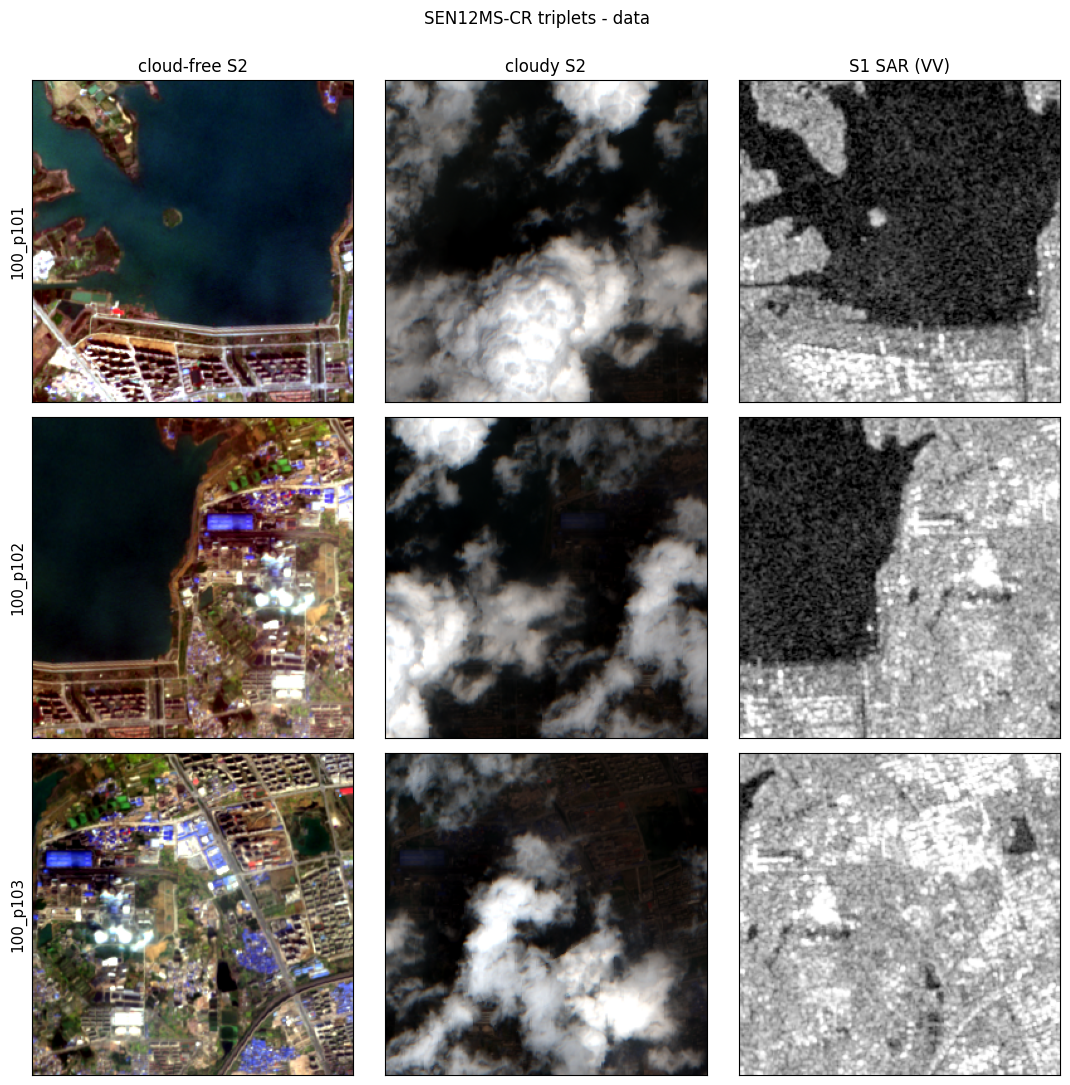

In [15]:
labels = list(MODS.keys())
fig, axes = plt.subplots(N_TRIPLETS, 3, squeeze=False,
                         figsize=(11, 3.6 * N_TRIPLETS))

for row, pid in enumerate(triplet_ids):
    for col, label in enumerate(labels):
        ax = axes[row][col]
        arr = load(indices[label][pid])
        if label.startswith('S1'):
            ax.imshow(s1_to_gray(arr), cmap='gray')
        else:
            ax.imshow(s2_to_rgb(arr))
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(label)
        if col == 0:
            ax.set_ylabel(pid, fontsize=11)

fig.suptitle(f'SEN12MS-CR triplets - {DATA_ROOT}', y=1.0)
fig.tight_layout()
plt.show()

**Notes**

- **S2 RGB** uses bands B4/B3/B2 (0-indexed `3, 2, 1`) — the same RGB-like bands
  the Phase 1 constraint loss projects to. Pixel values are reflectance x10000;
  the display applies a per-band 2-98th-percentile contrast stretch.
- **S1 SAR** shows the VV channel; values are backscatter in dB, clipped to
  `[-25, 0]` for display (matching the SAR normalisation in `dump/dataLoader.py`).
- Edit `N_TRIPLETS` to view more rows, or `RGB_BANDS` to try other band combos
  (e.g. `(7, 3, 2)` for a near-infrared false-colour composite).

/resnick/home/kwei2/miniforge3/envs/emrdm/lib/python3.10/site-packages/rasterio/__init__.py:304: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


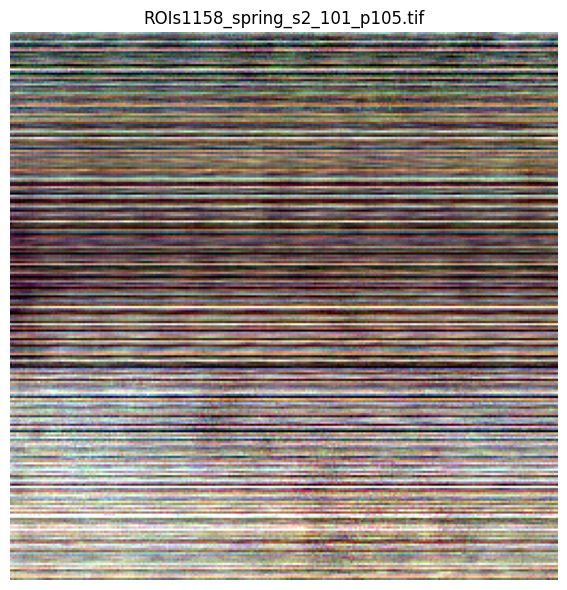

Shape: (13, 256, 256)  dtype: float32  min=0.0023  max=0.2726


In [3]:
def show_tif(path, bands=(3, 2, 1), percentile=(2, 98), figsize=(6, 6)):
    """Display any .tif file.

    - 1-band: grayscale with percentile stretch
    - 2-band: shows band 0 as grayscale (e.g. S1 VV)
    - 3-band: shown as RGB
    - 4+ bands: uses `bands` tuple to pick R, G, B (default B4/B3/B2 for S2)
    """
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)

    n_bands = arr.shape[0]

    if n_bands == 1:
        img = arr[0]
        lo, hi = np.percentile(img, percentile)
        img = np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)
        cmap = 'gray'
        display = img
    elif n_bands == 2:
        img = arr[0]                          # VV channel (e.g. S1)
        lo, hi = np.percentile(img, percentile)
        display = np.clip((img - lo) / (hi - lo + 1e-8), 0, 1)
        cmap = 'gray'
    elif n_bands == 3:
        rgb = arr
        out = np.empty_like(rgb)
        for c in range(3):
            lo, hi = np.percentile(rgb[c], percentile)
            out[c] = np.clip((rgb[c] - lo) / (hi - lo + 1e-8), 0, 1)
        display = np.transpose(out, (1, 2, 0))
        cmap = None
    else:
        idx = [b for b in bands if b < n_bands]
        rgb = arr[idx]
        out = np.empty_like(rgb)
        for c in range(len(idx)):
            lo, hi = np.percentile(rgb[c], percentile)
            out[c] = np.clip((rgb[c] - lo) / (hi - lo + 1e-8), 0, 1)
        display = np.transpose(out, (1, 2, 0))
        cmap = None

    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(display, cmap=cmap)
    ax.set_title(Path(path).name)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    print(f"Shape: {arr.shape}  dtype: {arr.dtype}  "
          f"min={arr.min():.4f}  max={arr.max():.4f}")

# ---- edit this path ----
show_tif('../results/sample/ROIs1158_spring_s2_101_p105.tif')